## Step 2: Load and Preprocess the Dataset

In [4]:
import pandas as pd
import os


dataset_path = "spotify_top_1000_tracks.csv"

# Load dataset
df = pd.read_csv(dataset_path, encoding="utf-8")

# Convert release_date and extract year
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce') 
df['year'] = df['release_date'].dt.year

# The 'duration_min' column is already in this CSV, so we are ready!
print("Dataset loaded and basic preprocessing complete!")
print(df.head(3))

Dataset loaded and basic preprocessing complete!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1Srtv4MB   
2  https://open.spotify.com/track/0TK2YIli7K1leLo...  0TK2YIli7K1leLovkQiNik   

   duration_min    year  
0      3.869767  2018.0  
1      3.840883  2016.0  
2      3.182667  2019.0  


## Step 3: Data Cleaning and Feature Engineering

In [5]:
import numpy as np

# Clean up text columns
df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()
df['album'] = df['album'].str.strip()

# Convert 'year' to integer
df['year'] = df['year'].fillna(0).astype(int)

# Drop unnecessary columns
cols_to_drop = ['spotify_url', 'id', 'release_date']

# Check for extra audio feature columns to clean up
for col in ['time_signature', 'key', 'mode']:
    if col in df.columns:
        cols_to_drop.append(col)

df = df.drop(columns=cols_to_drop, errors='ignore')

# Feature Engineering: Tempo Category
tempo_bins = [0, 100, 140, np.inf]
tempo_labels = ['Slow', 'Medium', 'Fast']

if 'tempo' in df.columns:
    df['tempo_category'] = pd.cut(df['tempo'], bins=tempo_bins, labels=tempo_labels, right=False)
    print("Feature 'tempo_category' created.")
else:
    print("Warning: 'tempo' column not found; skipping.")

# Remove duplicates
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')

print(f"Data cleaning complete. Final Row Count: {len(df)}")

Data cleaning complete. Final Row Count: 971


## 1. Histogram - Distribution of Popularity

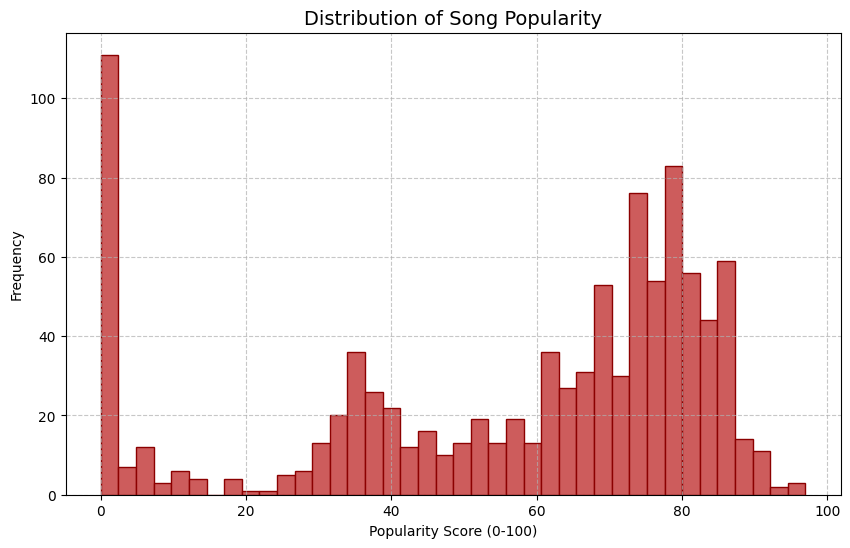

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=40, color='indianred', edgecolor='darkred')
plt.title('Distribution of Song Popularity', fontsize=14)
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 1.1 Try It

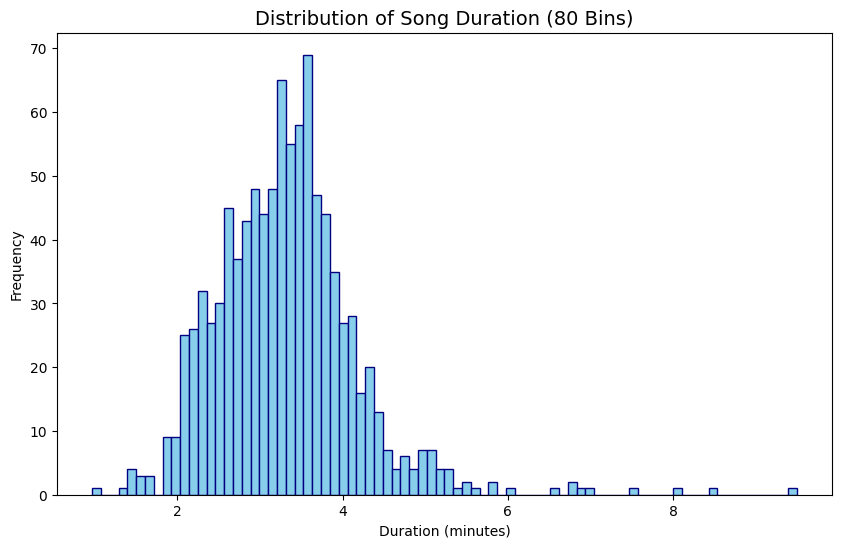

In [7]:
plt.figure(figsize=(10, 6))
# Changing bins to 80 and using duration_min
plt.hist(df['duration_min'], bins=80, color='skyblue', edgecolor='navy')
plt.title('Distribution of Song Duration (80 Bins)', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

## 2. Boxplot - Popularity Distribution by Year

C:\Users\farah\AppData\Local\Temp\ipykernel_3240\1229301356.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='viridis')


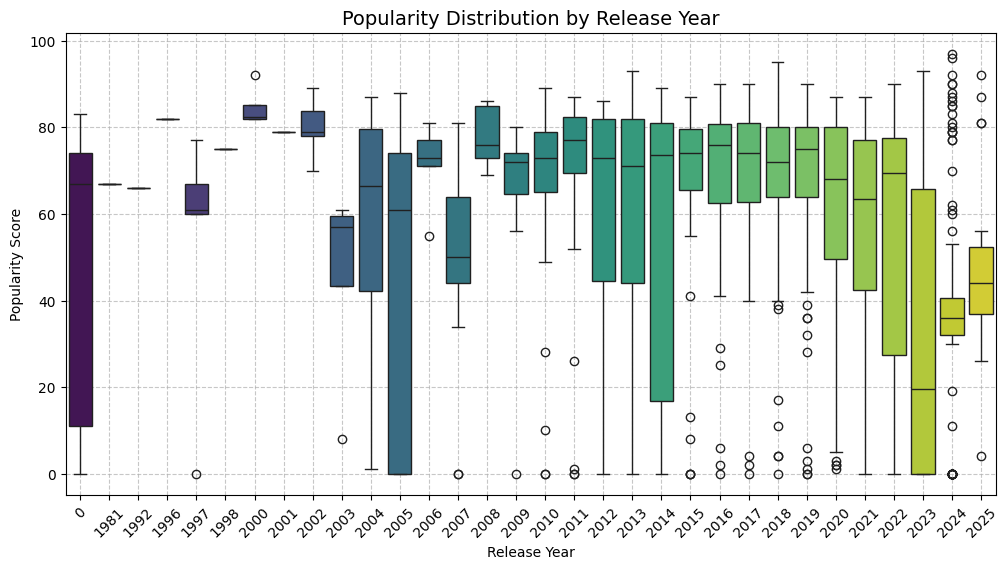

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data=df, palette='viridis')
plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 2.1 Try It

C:\Users\farah\AppData\Local\Temp\ipykernel_3240\785461601.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='magma')


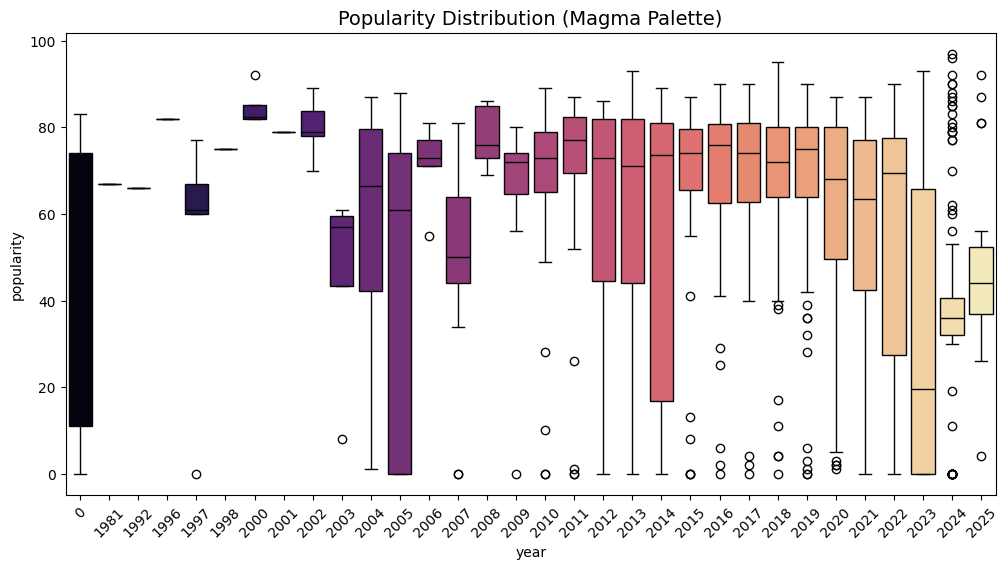

In [9]:
plt.figure(figsize=(12, 6))
# Using 'magma' palette
sns.boxplot(x='year', y='popularity', data=df, palette='magma')
plt.title('Popularity Distribution (Magma Palette)', fontsize=14)
plt.xticks(rotation=45)
plt.show()

## 3. Scatter Plot - Duration vs Popularity

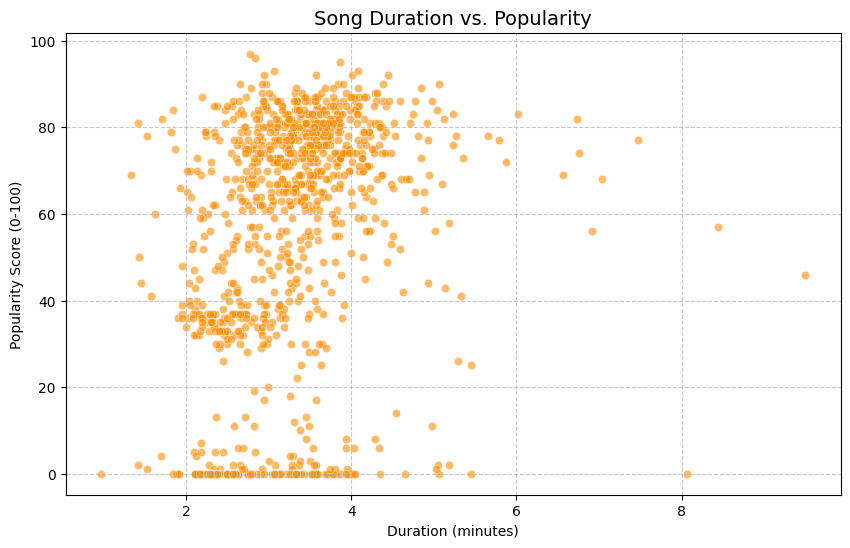

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.6, color='darkorange')
plt.title('Song Duration vs. Popularity', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 3.1 Try It

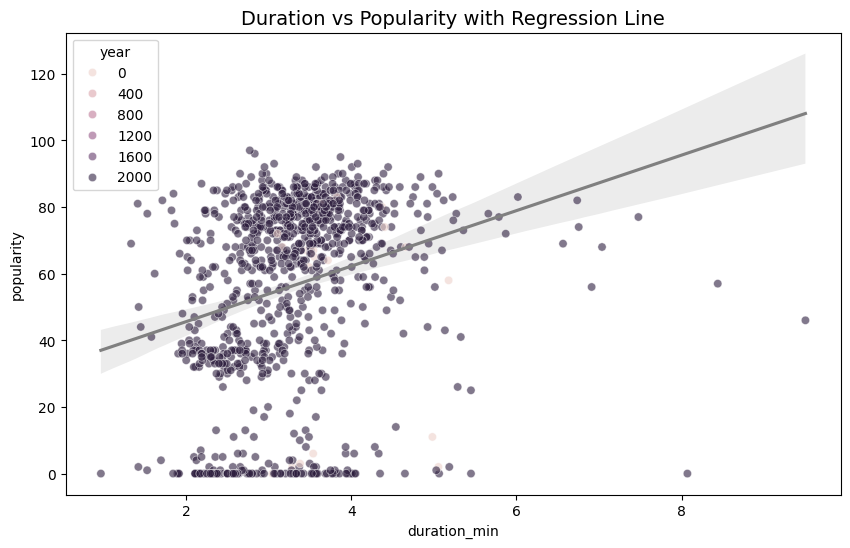

In [11]:
plt.figure(figsize=(10, 6))
# Adding regression line (grey) on top of the scatter
sns.regplot(x='duration_min', y='popularity', data=df, scatter=False, color='grey')
sns.scatterplot(x='duration_min', y='popularity', data=df, hue='year', alpha=0.6)
plt.title('Duration vs Popularity with Regression Line', fontsize=14)
plt.show()

## 4. Pair Plot - Feature Relationships Overview

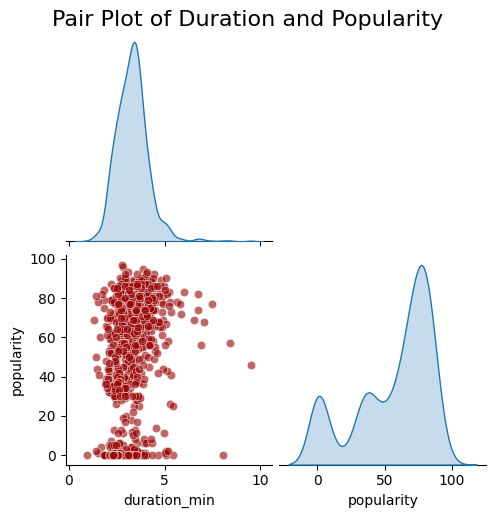

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

key_features = ['duration_min', 'popularity']
sns.pairplot(
    df[key_features],
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 'color': '#990000'}
)
plt.suptitle('Pair Plot of Duration and Popularity', y=1.02, fontsize=16)
plt.show()

## 4.1 Try It

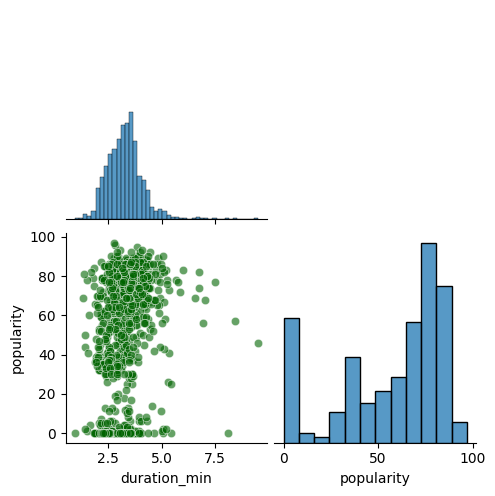

In [13]:
sns.pairplot(
    df[key_features],
    diag_kind='hist', # Changed to histogram
    corner=True,
    plot_kws={'alpha': 0.6, 'color': 'darkgreen'}
)
plt.show()

## 5. Joint Plot - Duration vs. Popularity Distribution

<Figure size 800x800 with 0 Axes>

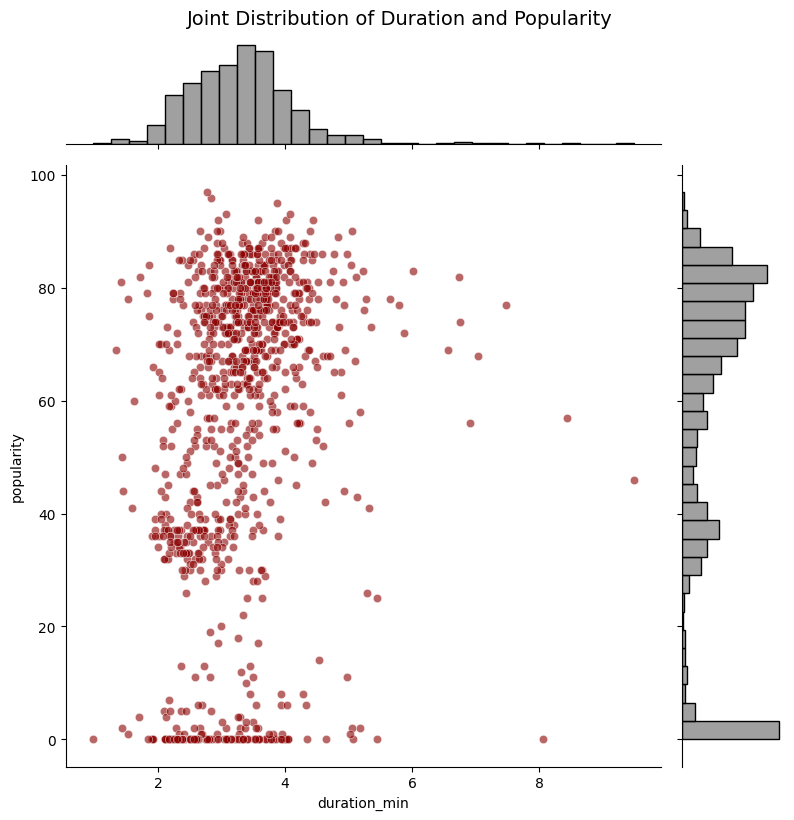

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='scatter',
    height=8,
    marginal_kws={'bins': 30, 'color': 'gray', 'edgecolor': 'black'},
    joint_kws={'alpha': 0.6, 'color': 'darkred'}
)
plt.suptitle('Joint Distribution of Duration and Popularity', y=1.02, fontsize=14)
plt.show()

## 5.1 Try It

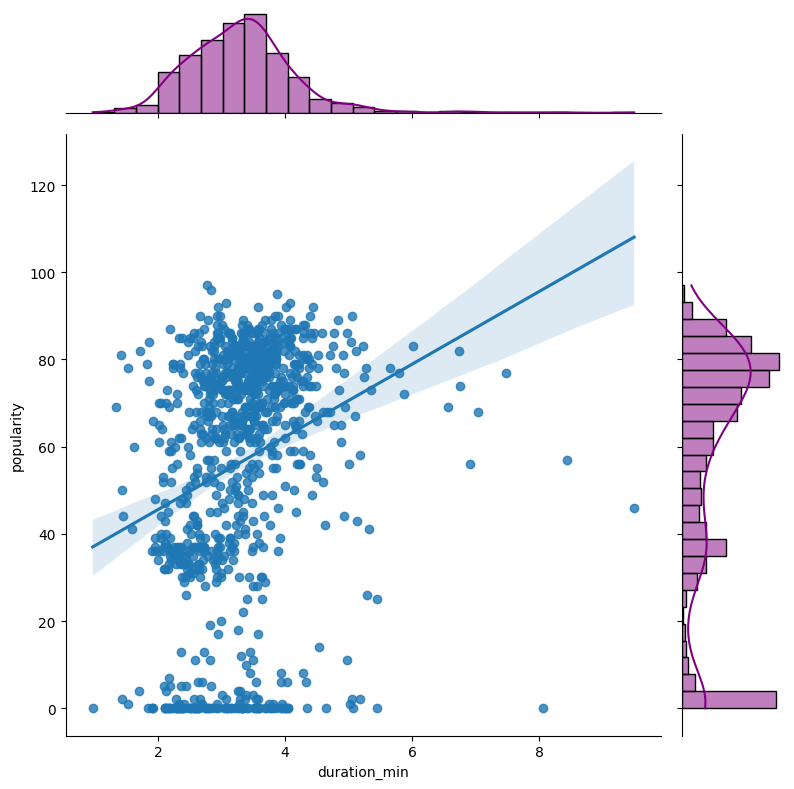

In [15]:
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='reg', # Changed to regression
    height=8,
    marginal_kws=dict(bins=25, color='purple')
)
plt.show()

## 6. Animated Line Chart

In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser

# Prep data
yearly_popularity = df.groupby('year')['popularity'].mean().reset_index().sort_values('year')

# Initialize Figure
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)
line, = ax.plot([], [], color='royalblue', linewidth=2.5, label='Average Popularity')

ax.set_title("Evolution of Track Popularity Over Time", fontsize=14, color='navy')
ax.set_xlabel("Year of Release")
ax.set_ylabel("Average Popularity")
ax.legend(loc="upper left")
plt.tight_layout()

def animate(i):
    x = yearly_popularity['year'][:i]
    y = yearly_popularity['popularity'][:i]
    line.set_data(x, y)
    return line,

# Create and Save
ani = FuncAnimation(fig, animate, frames=len(yearly_popularity), interval=100, repeat=False)
gif_path = os.path.abspath("yearly_popularity_trend.gif")
ani.save(gif_path, writer=PillowWriter(fps=10))

print(f"GIF saved successfully at: {gif_path}")
webbrowser.open(f"file://{gif_path}")
plt.close(fig)

GIF saved successfully at: c:\Users\farah\OneDrive\Documents\VsCode\Lab7_DataVisulization\yearly_popularity_trend.gif


## 6.1 Try It

In [17]:
ani = FuncAnimation(fig, animate, frames=len(yearly_popularity), interval=60, repeat=False)

gif_path = os.path.abspath("yearly_popularity_trend_fast.gif")
ani.save(gif_path, writer=PillowWriter(fps=10))
print(f"GIF saved successfully at: {gif_path}")

webbrowser.open(f"file://{gif_path}") 
plt.close(fig)

GIF saved successfully at: c:\Users\farah\OneDrive\Documents\VsCode\Lab7_DataVisulization\yearly_popularity_trend_fast.gif
